In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


path='D:\\DATA\\Projets\\M1_EEG_Project\\' # specify the path to the folder containing the data file/

session='data' # specify the name of the session folder

# filename='BrainFlow-RAW_2026-09-14_09-05-14_17.csv' # specify the name of the data file
filename='auditory_test.csv' # specify the name of the data file

# filename='openbci_simulated_N100P200_tab_sans_entete.csv' # specify the name of the data file

data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame  

stimulus=data[13]


C:\Users\Nicolas Catz\AppData\Local\Temp\ipykernel_21768\117992078.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame


In [13]:
threshold = (stimulus.max() + stimulus.min()) / 2
above = stimulus > threshold

onset_mask = above & ~above.shift(1, fill_value=False)
onsets = stimulus.index[onset_mask]

print(f"Detected {len(onsets)} stimulus onsets at indices: {onsets.tolist()}")

eeg_data=data.iloc[:, 1:9]  # select the EEG data columns (assuming they are in columns 1 to 8)
eeg_data=eeg_data.to_numpy()  # convert the DataFrame to a NumPy array for easier processing
eeg_data=eeg_data.T


Detected 120 stimulus onsets at indices: [1938, 2268, 2564, 2885, 3228, 3558, 3851, 4115, 4440, 4737, 5070, 5427, 5730, 6038, 6363, 6659, 6943, 7230, 7539, 7893, 8224, 8515, 8863, 9210, 9522, 9786, 10065, 10369, 10663, 11023, 11330, 11594, 11898, 12170, 12486, 12835, 13150, 13484, 13799, 14132, 14404, 14705, 15017, 15299, 15618, 15956, 16235, 16579, 16846, 17167, 17440, 17739, 18064, 18372, 18641, 18923, 19232, 19583, 19863, 20149, 20479, 20788, 21150, 21487, 21798, 22110, 22456, 22745, 23057, 23354, 23667, 24028, 24336, 24686, 24993, 25269, 25598, 25934, 26213, 26564, 26864, 27148, 27427, 27747, 28056, 28340, 28663, 29002, 29305, 29649, 30000, 30357, 30704, 30968, 31320, 31598, 31884, 32172, 32513, 32802, 33164, 33518, 33821, 34168, 34520, 34837, 35111, 35437, 35782, 36057, 36398, 36703, 37024, 37356, 37666, 38000, 38336, 38699, 39023, 39312]


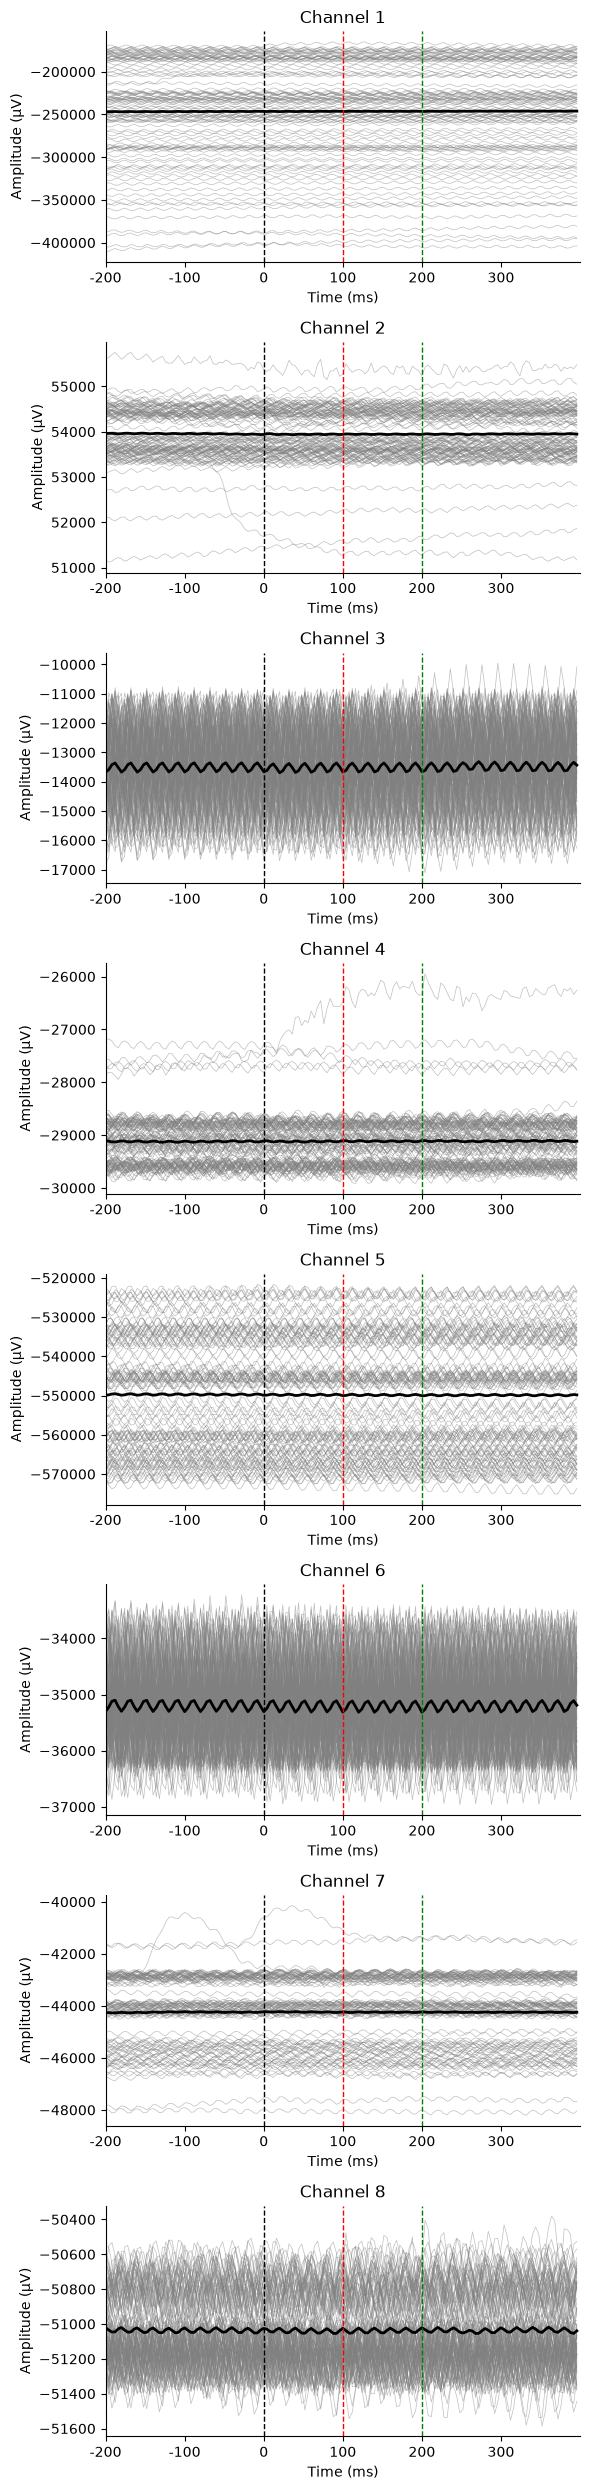

In [14]:
fig,axs=plt.subplots(8,1,figsize=(6,25))

for channel in range(0,8):  # Only process the first channel
    
    raw_signal = eeg_data[channel, :-2]

    pre=50
    post=100
    eegaligned = []
    for time in onsets:
        # print(f"Aligning EEG data for channel {channel} at time {time}")
        eegaligned.append(raw_signal[time-pre:time+post])

    axs[channel].plot(np.transpose(eegaligned),'gray', alpha=0.5,lw=0.5)
    axs[channel].plot(np.mean(eegaligned, axis=0), 'k', linewidth=2)
    axs[channel].axvline(50, color='black', linestyle='--', linewidth=1)
    axs[channel].axvline(75, color='red', linestyle='--', linewidth=1)
    axs[channel].axvline(100, color='green', linestyle='--', linewidth=1)
    axs[channel].set_title(f'Channel {channel+1}')
    axs[channel].set_xlabel('Time (ms)')
    axs[channel].set_ylabel('Amplitude (µV)')
    axs[channel].set_xlim(0, 150)
    # axs[channel].set_ylim(-200, 200)
    axs[channel].set_xticks([0,25,50, 75, 100, 125], ['-200', '-100', '0', '100', '200', '300'])
    axs[channel].spines['top'].set_visible(False)
    axs[channel].spines['right'].set_visible(False)
plt.tight_layout()  
  